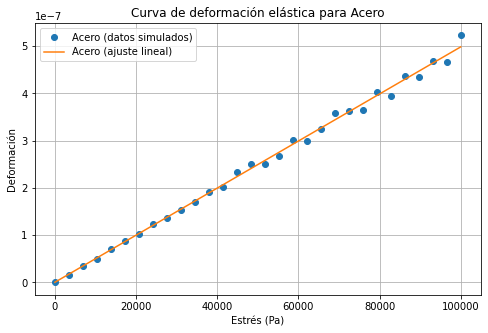


Resultados para Acero:
  Módulo de Young teórico: 200 GPa
  Módulo de Young promedio simulado: 200.36 GPa
  Incertidumbre (95%): ±2.00 GPa
  Ajuste lineal (deformación vs estrés):
    Pendiente: 4.982458e-12 1/Pa
    Intercepto: 3.755359e-10
    R-cuadrado: 0.9965

Tabla de datos simulados para Acero:
   Fuerza (N)   Deformación   Estrés (Pa)
0    0.000000  0.000000e+00      0.000000
1   34.482759  1.678933e-08   3448.275862
2   68.965517  3.438490e-08   6896.551724
3  103.448276  4.977887e-08  10344.827586
4  137.931034  7.100312e-08  13793.103448 



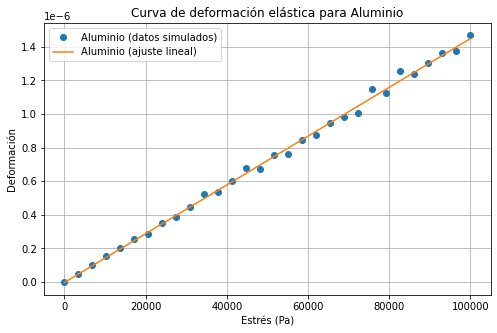


Resultados para Aluminio:
  Módulo de Young teórico: 69 GPa
  Módulo de Young promedio simulado: 69.01 GPa
  Incertidumbre (95%): ±0.71 GPa
  Ajuste lineal (deformación vs estrés):
    Pendiente: 1.451099e-11 1/Pa
    Intercepto: -2.094304e-09
    R-cuadrado: 0.9975

Tabla de datos simulados para Aluminio:
   Fuerza (N)   Deformación   Estrés (Pa)
0    0.000000  0.000000e+00      0.000000
1   34.482759  4.894745e-08   3448.275862
2   68.965517  1.022582e-07   6896.551724
3  103.448276  1.530141e-07  10344.827586
4  137.931034  2.055703e-07  13793.103448 



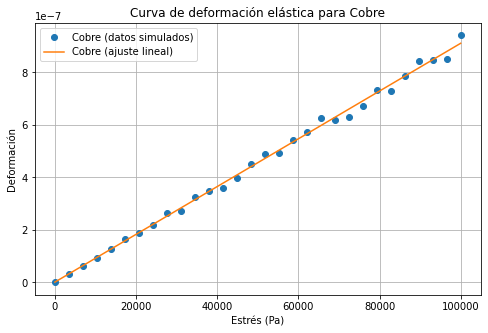


Resultados para Cobre:
  Módulo de Young teórico: 110 GPa
  Módulo de Young promedio simulado: 109.71 GPa
  Incertidumbre (95%): ±1.14 GPa
  Ajuste lineal (deformación vs estrés):
    Pendiente: 9.092880e-12 1/Pa
    Intercepto: 1.241226e-09
    R-cuadrado: 0.9969

Tabla de datos simulados para Cobre:
   Fuerza (N)   Deformación   Estrés (Pa)
0    0.000000  0.000000e+00      0.000000
1   34.482759  3.037249e-08   3448.275862
2   68.965517  6.365538e-08   6896.551724
3  103.448276  9.438862e-08  10344.827586
4  137.931034  1.260018e-07  13793.103448 



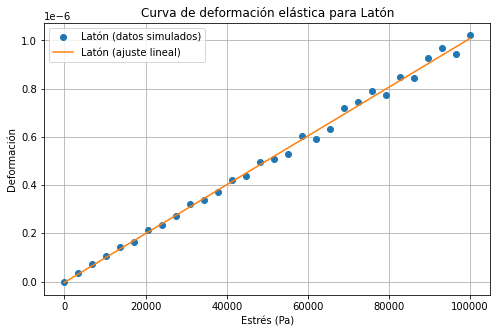


Resultados para Latón:
  Módulo de Young teórico: 100 GPa
  Módulo de Young promedio simulado: 99.48 GPa
  Incertidumbre (95%): ±1.16 GPa
  Ajuste lineal (deformación vs estrés):
    Pendiente: 1.012525e-11 1/Pa
    Intercepto: -3.893934e-09
    R-cuadrado: 0.9967

Tabla de datos simulados para Latón:
   Fuerza (N)   Deformación   Estrés (Pa)
0    0.000000  0.000000e+00      0.000000
1   34.482759  3.500657e-08   3448.275862
2   68.965517  7.242034e-08   6896.551724
3  103.448276  1.056635e-07  10344.827586
4  137.931034  1.440688e-07  13793.103448 



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

# Constantes teóricas para el módulo de Young (GPa)
constantes = {
    "Acero": 200,  # Módulo de Young para el acero
    "Aluminio": 69,  # Módulo de Young para el aluminio
    "Cobre": 110,  # Módulo de Young para el cobre
    "Latón": 100  # Módulo de Young para el latón
}

# Función para simular mediciones con incertidumbre
def simular_mediciones(young_teorico, num_mediciones, incertidumbre_relativa):
    mediciones = young_teorico * (1 + np.random.uniform(-incertidumbre_relativa, incertidumbre_relativa, num_mediciones))
    return mediciones

# Generar datos simulados
num_mediciones = 30
incertidumbre_relativa = 0.05  # 5% de incertidumbre relativa

data = {}
for metal, young in constantes.items():
    data[metal] = simular_mediciones(young, num_mediciones, incertidumbre_relativa)

# Análisis de datos y presentación en tabla
tablas = {}
for metal, mediciones in data.items():
    promedio = np.mean(mediciones)
    desviacion_estandar = np.std(mediciones)
    incertidumbre = desviacion_estandar / np.sqrt(num_mediciones)

    # Simulamos un experimento de ley de Hooke
    fuerzas = np.linspace(0, 1000, num_mediciones)  # Fuerzas en N
    area = 0.01  # Área de la sección transversal en m²
    long_inicial = 1.0  # Longitud inicial en m
    deformaciones = fuerzas / (area * mediciones * 1e9)  # Deformación unitaria
    long_final = long_inicial * (1 + deformaciones)

    # Ajuste lineal: Deformación vs Estrés (Fuerza/Area)
    estres = fuerzas / area
    slope, intercept, r_value, p_value, std_err = linregress(estres, deformaciones)

    # Crear tabla con los datos simulados
    tabla = pd.DataFrame({
        "Fuerza (N)": fuerzas,
        "Deformación": deformaciones,
        "Estrés (Pa)": estres
    })
    tablas[metal] = tabla

    # Graficar ajuste lineal
    plt.figure(figsize=(8, 5))
    plt.plot(estres, deformaciones, 'o', label=f"{metal} (datos simulados)")
    plt.plot(estres, slope * estres + intercept, '-', label=f"{metal} (ajuste lineal)")
    plt.xlabel("Estrés (Pa)")
    plt.ylabel("Deformación")
    plt.title(f"Curva de deformación elástica para {metal}")
    plt.legend()
    plt.grid()
    plt.show()

    # Imprimir resultados
    print(f"\nResultados para {metal}:")
    print(f"  Módulo de Young teórico: {constantes[metal]} GPa")
    print(f"  Módulo de Young promedio simulado: {promedio:.2f} GPa")
    print(f"  Incertidumbre (95%): ±{2 * incertidumbre:.2f} GPa")
    print(f"  Ajuste lineal (deformación vs estrés):")
    print(f"    Pendiente: {slope:.6e} 1/Pa")
    print(f"    Intercepto: {intercept:.6e}")
    print(f"    R-cuadrado: {r_value**2:.4f}")
    print(f"\nTabla de datos simulados para {metal}:")
    print(tabla.head(), "\n")
